# Streaming Simulation

Replays a sample of the held-out test set against the live `/predict` endpoint,
recording fraud scores and latency for each transaction.
Sections below build up rolling metrics and distributions to evaluate the model in a streaming setting.

## 1. Imports + Setup

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.simulator import load_test_sample, run_simulation

API_URL      = "http://localhost:8000/predict"
PARQUET_PATH = Path.cwd().parent / "data" / "test_features.parquet"
N_SAMPLES    = 500
DELAY_MS     = 50    # ms between requests — set to 0 to run as fast as possible
WINDOW       = 50    # rolling window size for metric plots

## 2. Load + Sample

In [16]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(df):,} rows  |  fraud rate: {df['isFraud'].mean():.2%}")

sample = load_test_sample(df, n=N_SAMPLES)
print(f"Sample: {len(sample)} rows  |  fraud rate: {sample['isFraud'].mean():.2%}")
sample.head(3)

Loaded 118,109 rows  |  fraud rate: 3.44%
Sample: 500 rows  |  fraud rate: 4.80%


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,log_D6,D7_null_flag,log_D7,D8_null_flag,log_D8,D9_null_flag,log_D9,is_unknown_os,is_mobile,device_os
0,0,14060103,117.0,W,6429,321.0,150.0,visa,226.0,debit,...,NaN,1,NaN,1,NaN,1,NaN,1,0,NaN
1,0,15697916,97.0,W,15651,417.0,150.0,visa,226.0,debit,...,NaN,1,NaN,1,NaN,1,NaN,1,0,NaN
2,0,15081079,77.0,W,14631,476.0,150.0,visa,166.0,debit,...,NaN,1,NaN,1,NaN,1,NaN,1,0,NaN


## 3. Run Simulation

In [17]:
results = run_simulation(sample, url=API_URL, delay_ms=DELAY_MS)

print(f"Scored {len(results)} transactions")
print(f"Fraud alerts : {results['is_fraud'].sum()}  ({results['is_fraud'].mean():.2%})")
print(f"Avg latency  : {results['latency_ms'].mean():.1f} ms")
results.head()

Scored 500 transactions
Fraud alerts : 12  (2.40%)
Avg latency  : 95.7 ms


,fraud_probability,is_fraud,threshold,latency_ms,true_label
0,0.003495,False,0.154706,234.924708,0
1,0.010600,False,0.154706,204.584083,0
2,0.010483,False,0.154706,269.826042,0
3,0.011950,False,0.154706,168.814333,0
4,0.005220,False,0.154706,217.815292,0


## 4. Rolling Metrics

Rolling fraud alert rate, precision, and recall over the stream.
A window of 50 transactions gives a smooth signal while staying responsive to drift.

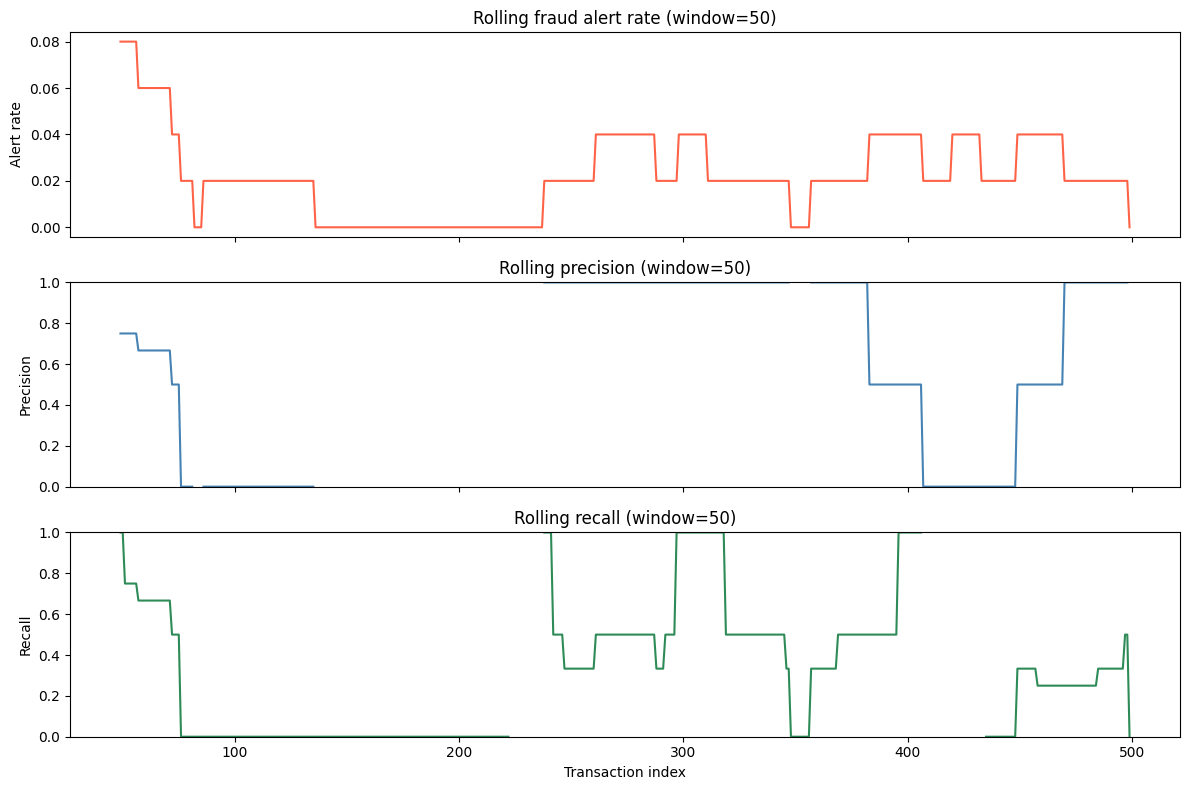

In [18]:
def rolling_precision(df, window):
    """TP / (TP + FP) in each rolling window."""
    tp = (df["is_fraud"] & (df["true_label"] == 1)).rolling(window).sum()
    fp = (df["is_fraud"] & (df["true_label"] == 0)).rolling(window).sum()
    return tp / (tp + fp).replace(0, float("nan"))

def rolling_recall(df, window):
    """TP / (TP + FN) in each rolling window."""
    tp = (df["is_fraud"] & (df["true_label"] == 1)).rolling(window).sum()
    fn = ((df["is_fraud"] == False) & (df["true_label"] == 1)).rolling(window).sum()
    denom = tp + fn
    return tp / denom.where(denom > 0)  # NaN where no fraud in window

idx = results.index

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(idx, results["is_fraud"].rolling(WINDOW).mean(), color="tomato")
axes[0].set_ylabel("Alert rate")
axes[0].set_title(f"Rolling fraud alert rate (window={WINDOW})")

axes[1].plot(idx, rolling_precision(results, WINDOW), color="steelblue")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Rolling precision (window={WINDOW})")
axes[1].set_ylim(0, 1)

axes[2].plot(idx, rolling_recall(results, WINDOW), color="seagreen")
axes[2].set_ylabel("Recall")
axes[2].set_title(f"Rolling recall (window={WINDOW})")
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("Transaction index")

plt.tight_layout()
plt.show()

## 5. Latency Plot

Per-request round-trip latency. Spikes indicate slow responses from the server.

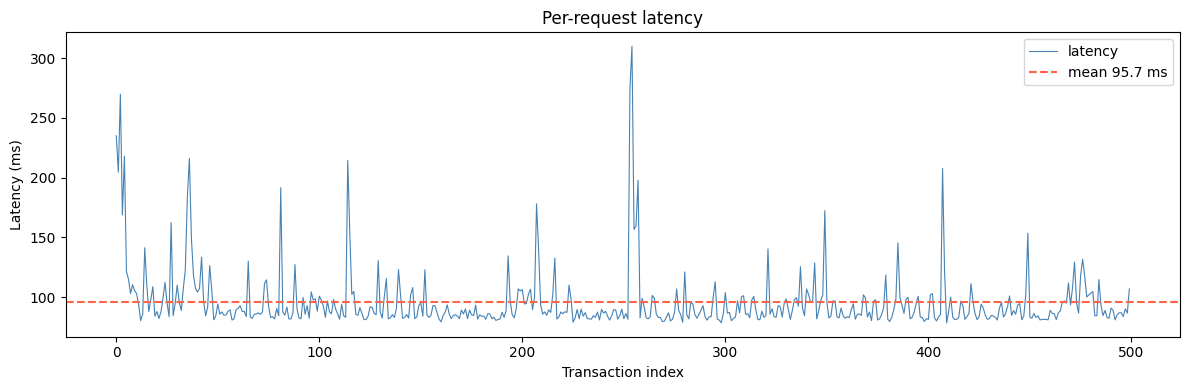

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(results.index, results["latency_ms"], color="steelblue", linewidth=0.8, label="latency")
ax.axhline(results["latency_ms"].mean(), color="tomato", linestyle="--",
           label=f"mean {results['latency_ms'].mean():.1f} ms")
ax.set_xlabel("Transaction index")
ax.set_ylabel("Latency (ms)")
ax.set_title("Per-request latency")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Score Distribution

Histogram of `fraud_probability` split by true label.
A well-calibrated model pushes fraud scores toward 1 and legitimate scores toward 0.

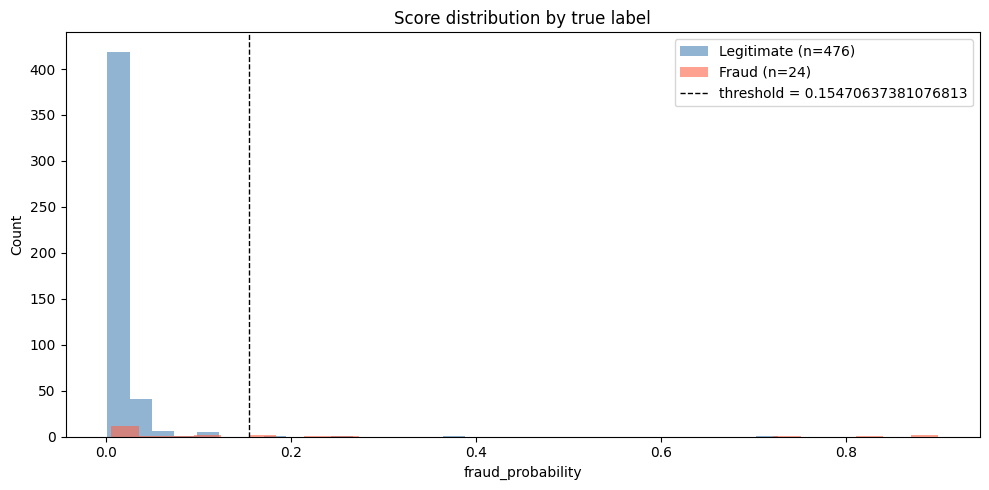

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

THRESHOLD = results['threshold'].unique()[0]

for label, color, name in [(0, "steelblue", "Legitimate"), (1, "tomato", "Fraud")]:
    subset = results[results["true_label"] == label]["fraud_probability"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{name} (n={len(subset)})")

ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"threshold = {THRESHOLD}")
ax.set_xlabel("fraud_probability")
ax.set_ylabel("Count")
ax.set_title("Score distribution by true label")
ax.legend()
plt.tight_layout()
plt.show()